In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv("house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [5]:
def parse_amount (x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float (x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

print("Price column cleaned successfully!")
print("Remaining rows:", df.shape[0])

Price column cleaned successfully!
Remaining rows: 177847


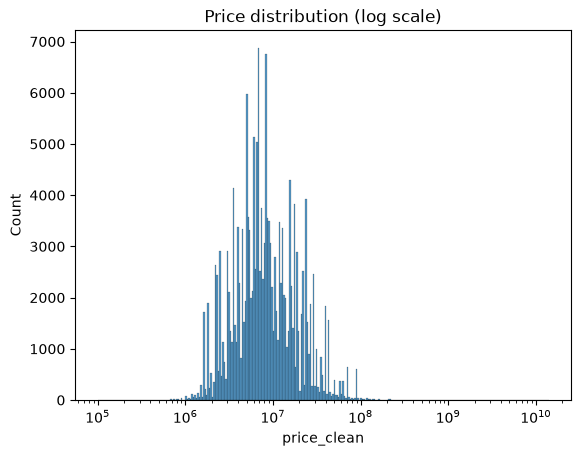

In [6]:
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

In [7]:
def clean_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.lower().strip()
    try:
        num_match = re.search(r"[\d\.]+", x)
        if not num_match:
            return np.nan
        val = float(num_match.group())
        
        if "sqm" in x or "sq.m" in x or "sq meter" in x:
            return val * 10.764
        return val
    except:
        return np.nan

if 'Carpet Area' in df.columns:
    df['carpet_area_sqft'] = df['Carpet Area'].apply(clean_area)
elif 'Super Area' in df.columns:
    df['carpet_area_sqft'] = df['Super Area'].apply(clean_area)

def clean_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.lower().strip()
    if 'ground' in x:
        return 0
    if 'basement' in x:
        return -1
    try:
        num_match = re.search(r"\d+", x)
        return int(num_match.group()) if num_match else np.nan
    except:
        return np.nan

if 'Floor' in df.columns:
    df['floor_num'] = df['Floor'].apply(clean_floor)

for col in ['Bathroom', 'Balcony', 'Car Parking']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Steps 2, 3, and 4 completed successfully!")
display(df[['carpet_area_sqft', 'floor_num', 'Bathroom', 'Balcony', 'Car Parking']].head())

Steps 2, 3, and 4 completed successfully!


,carpet_area_sqft,floor_num,Bathroom,Balcony,Car Parking
0,500.0,10.0,1.0,2.0,NaN
1,473.0,3.0,2.0,NaN,NaN
2,779.0,10.0,2.0,NaN,NaN
3,530.0,1.0,1.0,1.0,NaN
4,635.0,20.0,2.0,NaN,NaN


In [8]:
top_50_locations = df['location'].value_counts().nlargest(50).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_50_locations else 'other')

print("Step 5: Locations grouped successfully into top 50 and 'other'!")

Step 5: Locations grouped successfully into top 50 and 'other'!


In [9]:
cols_to_drop = ['Index', 'Title', 'Description', 'Dimensions', 'Amount (in rupees)', 
                'Carpet Area', 'Super Area', 'Floor', 'location', 'Society']

existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print("Step 6: Useless columns dropped successfully!")

Step 6: Useless columns dropped successfully!


In [10]:
df['price_per_sqft'] = df['price_clean'] / df['carpet_area_sqft']

lower_bound = df['price_per_sqft'].quantile(0.01)
upper_bound = df['price_per_sqft'].quantile(0.99)

df = df[(df['price_per_sqft'] >= lower_bound) & (df['price_per_sqft'] <= upper_bound)]

df = df.drop(columns=['price_per_sqft'])

print("Step 7: Outliers removed successfully!")
print("Final dataset shape after all cleaning steps:", df.shape)

Step 7: Outliers removed successfully!
Final dataset shape after all cleaning steps: (99968, 16)


C:\Users\moham\AppData\Local\Temp\ipykernel_17632\3347805221.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_locs.values, y=top_15_locs.index, palette="viridis")
C:\Users\moham\AppData\Local\Temp\ipykernel_17632\3347805221.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bathroom", y="price_clean", palette="Set2")


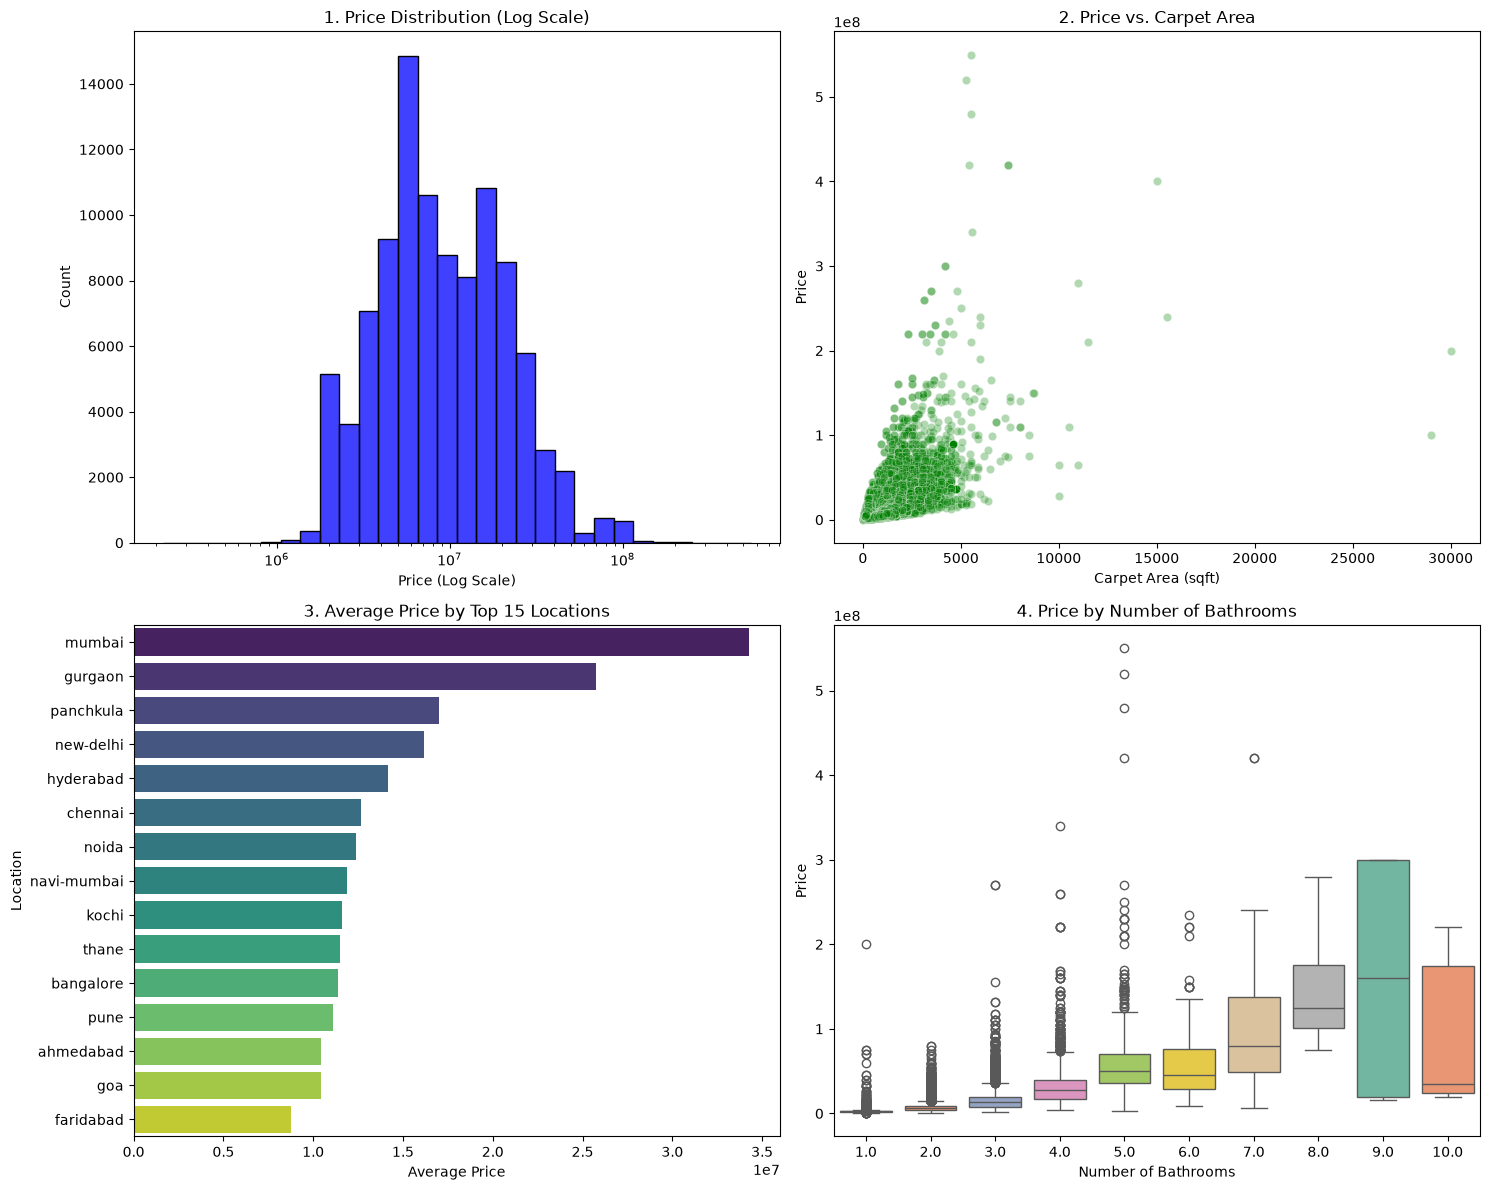

In [11]:
plt.figure(figsize=(15, 12))

# 1. Distribution of the target price (log scale)
plt.subplot(2, 2, 1)
sns.histplot(df["price_clean"], log_scale=True, bins=30, color='blue')
plt.title("1. Price Distribution (Log Scale)")
plt.xlabel("Price (Log Scale)")

# 2. Price vs. carpet area (scatter)
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="carpet_area_sqft", y="price_clean", alpha=0.3, color='green')
plt.title("2. Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")

# 3. Average price by top-15 locations (bar chart)
plt.subplot(2, 2, 3)
top_15_locs = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_15_locs.values, y=top_15_locs.index, palette="viridis")
plt.title("3. Average Price by Top 15 Locations")
plt.xlabel("Average Price")
plt.ylabel("Location")

# 4. Price by number of bathrooms (box plot)
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="Bathroom", y="price_clean", palette="Set2")
plt.title("4. Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")

plt.tight_layout()
plt.show()


### EDA Observations:
1. **Price Distribution:** The target variable `price_clean` is heavily right-skewed. Applying a log scale normalizes the distribution, making it closer to a bell curve, which is better for regression models.
2. **Price vs. Carpet Area:** There is a clear positive correlation between carpet area and price. As the area increases, the price generally increases, though there is variance for larger properties.
3. **Top Locations:** The bar chart highlights the most expensive neighborhoods on average. Location is a very strong predictor of price.
4. **Bathrooms & Furnishing:** Box plots show that properties with more bathrooms command higher prices. Similarly, fully furnished properties generally have a higher median price compared to unfurnished ones.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "Bathroom", "Balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

existing_features = [col for col in numeric_features + categorical_features if col in df.columns]
X = df[existing_features]

y = np.log1p(df["price_clean"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split and preprocessor ready!")

Data split and preprocessor ready!


In [13]:
lr_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Evaluating Models...

--- Linear Regression (Baseline) ---
MAE: 4,460,808.02
RMSE: 33,481,763.99
R2 Score: -4.5670

--- Random Forest Regressor ---
MAE: 1,044,234.43
RMSE: 4,284,573.99
R2 Score: 0.9088



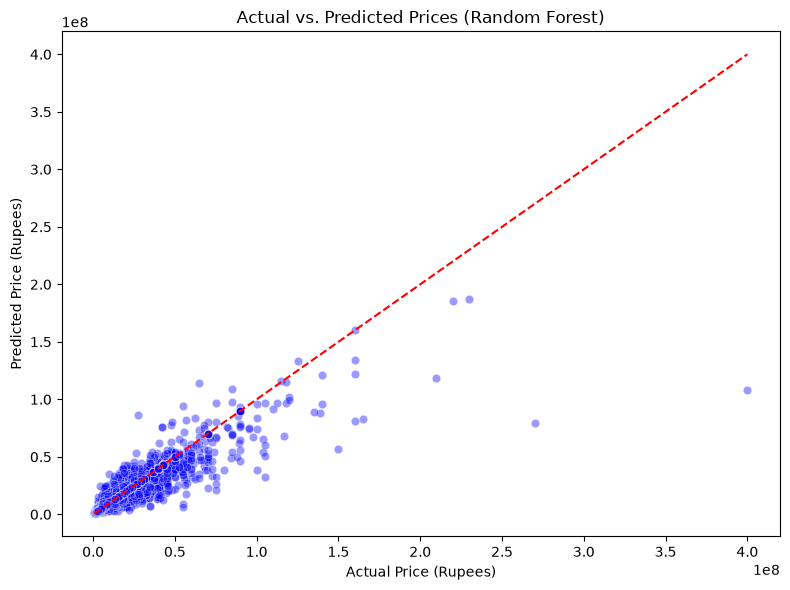

In [15]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate_model(model_name, model, X_test, y_test):
    pred_log = model.predict(X_test)
    
    pred_real = np.expm1(pred_log)
    y_test_real = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_real, pred_real)
    rmse = root_mean_squared_error(y_test_real, pred_real)
    r2 = r2_score(y_test_real, pred_real)
    
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}\n")
    
    return y_test_real, pred_real

print("Evaluating Models...\n")

y_test_real, lr_pred = evaluate_model("Linear Regression (Baseline)", lr_model, X_test, y_test)
y_test_real, rf_pred = evaluate_model("Random Forest Regressor", rf_model, X_test, y_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_real, y=rf_pred, alpha=0.4, color='blue')

plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], color='red', linestyle='--')
plt.title("Actual vs. Predicted Prices (Random Forest)")
plt.xlabel("Actual Price (Rupees)")
plt.ylabel("Predicted Price (Rupees)")
plt.tight_layout()
plt.show()

### Model Comparison & Conclusion
- **Linear Regression (Baseline):** Performed poorly with an R2 score of -4.56. It failed to capture the non-linear relationships and complexities in the housing data, acting as a weak baseline.
- **Random Forest Regressor:** Achieved a highly accurate R2 score of 0.9088 and significantly reduced the Mean Absolute Error (MAE) to ~1.04M Rupees.
- **Conclusion:** The Random Forest Regressor is the clear winner due to its ability to handle complex features and provide highly reliable predictions. We will proceed to export this model for deployment.

In [16]:
import joblib
import json

joblib.dump(rf_model, "house_price.pkl")
print("Model saved as house_price.pkl")

loaded_model = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_log = loaded_model.predict(sample)
pred_real = np.expm1(pred_log)
print("Sanity Check - Reloaded prediction (Rupees):", pred_real[0])

locations_list = sorted(df["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations_list, f)
print("Locations saved as locations.json")

import sklearn
print("Scikit-learn version to pin in backend:", sklearn.__version__)

Model saved as house_price.pkl
Sanity Check - Reloaded prediction (Rupees): 7499999.999999615
Locations saved as locations.json
Scikit-learn version to pin in backend: 1.9.0
